# 🔍 HDFS Log Anomaly Detection — End-to-End Production Pipeline

**Dataset:** HDFS_v1 (LogHub — Hadoop Distributed File System)  
**Environment:** Kaggle Notebooks  
**Goal:** Detect anomalous HDFS block sessions from raw log data using classical ML (Random Forest baseline) and a deep learning LSTM model.

---

## 📋 Table of Contents
1. [Environment Setup](#1-environment-setup)
2. [Data Loading & Understanding](#2-data-loading--understanding)
3. [Log Parsing & Preprocessing](#3-log-parsing--preprocessing)
4. [Feature Engineering](#4-feature-engineering)
5. [Baseline Model — Random Forest](#5-baseline-model--random-forest)
6. [Advanced Model — LSTM](#6-advanced-model--lstm)
7. [Evaluation & Metrics](#7-evaluation--metrics)
8. [End-to-End Inference Pipeline](#8-end-to-end-inference-pipeline)
9. [Visualizations](#9-visualizations)
10. [Model Persistence & Deployment Notes](#10-model-persistence--deployment-notes)

---
> **Architecture note:** Each log session corresponds to a single HDFS block ID. The pipeline groups raw log lines by block ID, parses them into event templates using a lightweight Drain-inspired regex parser, encodes the event sequences numerically, then classifies each session as **Normal** or **Anomaly**.

## 1. Environment Setup

### What this cell does
Imports all required libraries and sets global configuration constants (random seeds, paths, hyperparameters).  
### Why it is necessary
Centralising all imports and constants at the top ensures reproducibility and makes it trivial to tune the pipeline without hunting through code.  
### What output to expect
No output — this is a configuration cell. A confirmation print confirms the environment is ready.

In [6]:
import os
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout, Bidirectional, GlobalMaxPooling1D
)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings('ignore')

# ─── Reproducibility ─────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ─── Dataset paths (Kaggle environment) ──────
INPUT_ROOT = '/kaggle/input'
OUTPUT_DIR = '/kaggle/working'

# ─── Pipeline hyperparameters ────────────────
MAX_SEQ_LEN    = 50      # max events per session (truncate/pad)
EMBEDDING_DIM  = 64      # LSTM embedding size
LSTM_UNITS     = 128     # LSTM hidden units
DROPOUT_RATE   = 0.3
EPOCHS         = 6
TEST_SIZE      = 0.2
VAL_SIZE       = 0.1

# ─── Dual GPU Setup ──────────────────────────
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# Initialize MirroredStrategy for synchronous distributed training
strategy = tf.distribute.MirroredStrategy()
print(f"Number of devices in sync: {strategy.num_replicas_in_sync}")

# Scale the batch size for dual T4s (16GB VRAM each)
PER_REPLICA_BATCH_SIZE = 128 
GLOBAL_BATCH_SIZE = PER_REPLICA_BATCH_SIZE * strategy.num_replicas_in_sync
print(f"Global Batch Size: {GLOBAL_BATCH_SIZE}")

# ─── Plot style ──────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('Set2')

print("✅ Environment ready — TensorFlow", tf.__version__)
print("   Working directory:", OUTPUT_DIR)

Num GPUs Available:  2
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices in sync: 2
Global Batch Size: 256
✅ Environment ready — TensorFlow 2.19.0
   Working directory: /kaggle/working


## 2. Data Loading & Understanding

### What this cell does
Dynamically inspects the Kaggle `/kaggle/input/` directory to locate the HDFS log file (`HDFS.log`) and the ground-truth labels file (`anomaly_label.csv`).  
### Why it is necessary
Kaggle dataset slugs vary slightly depending on how the dataset was added. Dynamic inspection is more robust than hard-coding a path and prevents silent file-not-found errors.  
### What output to expect
- A printed directory tree showing available files
- The resolved path to the log file and the labels file.

In [18]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ayenuryrr/loghub-hdfs-hadoop-distributed-file-system-data/HDFS_2k/HDFS_2k.log
/kaggle/input/datasets/ayenuryrr/loghub-hdfs-hadoop-distributed-file-system-data/HDFS_2k/HDFS_2k.log_structured.csv
/kaggle/input/datasets/ayenuryrr/loghub-hdfs-hadoop-distributed-file-system-data/HDFS_2k/HDFS_2k.log_templates.csv
/kaggle/input/datasets/ayenuryrr/loghub-hdfs-hadoop-distributed-file-system-data/HDFS_v3_TraceBench/README.md
/kaggle/input/datasets/ayenuryrr/loghub-hdfs-hadoop-distributed-file-system-data/HDFS_v3_TraceBench/tracebench/convert_sql_to_csv.py
/kaggle/input/datasets/ayenuryrr/loghub-hdfs-hadoop-distributed-file-system-data/HDFS_v3_TraceBench/tracebench/AN_Proc_suspendDN_w_35FDN_30C_1to19B_0to600INT_15RT_5WT/event.csv
/kaggle/input/datasets/ayenuryrr/loghub-hdfs-hadoop-distributed-file-system-data/HDFS_v3_TraceBench/tracebench/AN_Proc_suspendDN_w_35FDN_30C_1to19B_0to600INT_15RT_5WT/trace.csv
/kaggle/input/datasets/ayenuryrr/loghub-hdfs-hadoop-distributed-file-sy

In [19]:
import os

# Set the root directory specifically for Kaggle's environment
INPUT_ROOT = '/kaggle/input'

def find_file(root: str, filename: str) -> str:
    """Recursively search for a file under `root`. Returns the full path."""
    for dirpath, _, filenames in os.walk(root):
        for f in filenames:
            if f.lower() == filename.lower():
                return os.path.join(dirpath, f)
    return None

# ── Resolve file paths ─────────────────────────────────────────────
LOG_PATH   = find_file(INPUT_ROOT, 'HDFS.log')
LABEL_PATH = find_file(INPUT_ROOT, 'anomaly_label.csv')

# Fallback: some Kaggle uploads name it differently
if LOG_PATH is None:
    LOG_PATH = find_file(INPUT_ROOT, 'HDFS_v1.log')
if LABEL_PATH is None:
    LABEL_PATH = find_file(INPUT_ROOT, 'anomaly_label.csv')

assert LOG_PATH   is not None, "❌ HDFS.log not found — check 'Add Data' in your Kaggle notebook."
assert LABEL_PATH is not None, "❌ anomaly_label.csv not found — check 'Add Data'."

print(f"\n✅ Log file   : {LOG_PATH}")
print(f"✅ Label file : {LABEL_PATH}")


✅ Log file   : /kaggle/input/datasets/ayenuryrr/loghub-hdfs-hadoop-distributed-file-system-data/HDFS_v1/HDFS.log
✅ Label file : /kaggle/input/datasets/ayenuryrr/loghub-hdfs-hadoop-distributed-file-system-data/HDFS_v1/preprocessed/anomaly_label.csv


### What this cell does
Loads the raw HDFS log file line-by-line into a DataFrame and the label CSV into a separate DataFrame.  
### Why it is necessary
We need both objects in memory to (a) parse and group log lines into sessions and (b) attach ground-truth labels before model training.  
### What output to expect
- Shape of both DataFrames
- First 5 rows of each
- Class distribution of labels

In [20]:
# ─── Load raw log lines ──────────────────────────────────────────────────────
print("Loading HDFS.log ...")
with open(LOG_PATH, 'r', encoding='utf-8', errors='replace') as f:
    raw_lines = f.readlines()

df_logs = pd.DataFrame({'raw_line': [l.rstrip('\n') for l in raw_lines]})
print(f"  Total log lines : {len(df_logs):,}")

# ─── Load labels & Split 97% / 3% ────────────────────────────────────────────
print("\nLoading anomaly_label.csv ...")
df_labels = pd.read_csv(LABEL_PATH)
df_labels.columns = [c.strip() for c in df_labels.columns]

# Normalise the block_id column name immediately
label_col = [c for c in df_labels.columns if 'block' in c.lower()][0]
df_labels = df_labels.rename(columns={label_col: 'block_id'})
df_labels['block_id'] = df_labels['block_id'].str.strip()

# Create the master split at the Block ID level
df_labels_dev, df_labels_inf = train_test_split(
    df_labels, 
    test_size=0.03,            # 3% for pure inference holdout
    random_state=SEED, 
    stratify=df_labels['Label'] # Ensure anomalies exist in the 3%
)

# Create fast-lookup sets
DEV_BLOCKS = set(df_labels_dev['block_id'])
INF_BLOCKS = set(df_labels_inf['block_id'])

print(f"  Total blocks       : {len(df_labels):,}")
print(f"  Dev blocks (97%)   : {len(DEV_BLOCKS):,}")
print(f"  Inf blocks  (3%)   : {len(INF_BLOCKS):,}")
print(f"\n  Inf anomaly rate   : {(df_labels_inf['Label'] == 'Anomaly').mean()*100:.2f}%")

Loading HDFS.log ...
  Total log lines : 11,175,629

Loading anomaly_label.csv ...
  Total blocks       : 575,061
  Dev blocks (97%)   : 557,809
  Inf blocks  (3%)   : 17,252

  Inf anomaly rate   : 2.93%


### What this cell does
Performs exploratory data analysis (EDA) — examining the raw log format, extracting sample block IDs, and characterising log-level distribution.  
### Why it is necessary
Understanding the raw format is essential before writing the parser. The HDFS log follows a strict structure: `Date Time Level Component: Message`. We need to confirm this before designing regex patterns.  
### What output to expect
- Printed log format breakdown
- Distribution of severity levels (INFO / WARN / ERROR / FATAL)

In [21]:
# ── Understand the log format ─────────────────────────────────────
# HDFS log format: <Date> <Time> <PID> <Level> <Component>: <Content>
# Example: 081109 203615 148 INFO dfs.DataNode$PacketResponder: ...

HDFS_LOG_RE = re.compile(
    r'^(?P<date>\d{6})\s+'
    r'(?P<time>\d{6})\s+'
    r'(?P<pid>\d+)\s+'
    r'(?P<level>\w+)\s+'
    r'(?P<component>[\w.$]+):\s+'
    r'(?P<content>.+)$'
)

sample = df_logs['raw_line'].iloc[:5].tolist()
print("Log format anatomy:")
for line in sample:
    m = HDFS_LOG_RE.match(line)
    if m:
        for k, v in m.groupdict().items():
            print(f"  {k:12s}: {v}")
        print()

# ── Log level distribution ─────────────────────────────────────────
levels = []
for line in df_logs['raw_line']:
    m = HDFS_LOG_RE.match(line)
    if m:
        levels.append(m.group('level'))
    else:
        levels.append('UNPARSED')

level_counts = Counter(levels)
print("Log level distribution:")
for lvl, cnt in level_counts.most_common():
    print(f"  {lvl:10s}: {cnt:,}  ({cnt/len(levels)*100:.1f}%)")

Log format anatomy:
  date        : 081109
  time        : 203518
  pid         : 143
  level       : INFO
  component   : dfs.DataNode$DataXceiver
  content     : Receiving block blk_-1608999687919862906 src: /10.250.19.102:54106 dest: /10.250.19.102:50010

  date        : 081109
  time        : 203518
  pid         : 35
  level       : INFO
  component   : dfs.FSNamesystem
  content     : BLOCK* NameSystem.allocateBlock: /mnt/hadoop/mapred/system/job_200811092030_0001/job.jar. blk_-1608999687919862906

  date        : 081109
  time        : 203519
  pid         : 143
  level       : INFO
  component   : dfs.DataNode$DataXceiver
  content     : Receiving block blk_-1608999687919862906 src: /10.250.10.6:40524 dest: /10.250.10.6:50010

  date        : 081109
  time        : 203519
  pid         : 145
  level       : INFO
  component   : dfs.DataNode$DataXceiver
  content     : Receiving block blk_-1608999687919862906 src: /10.250.14.224:42420 dest: /10.250.14.224:50010

  date        : 

## 3. Log Parsing & Preprocessing

### What this cell does
Implements a lightweight **Drain-inspired log parser** using regex. It extracts:
- The block ID (session key) from log message content
- A normalised event template (dynamic values replaced with `<*>`)

### Why it is necessary
Raw log lines contain dynamic values (block IDs, IP addresses, file paths, numbers) that vary on every line but carry the same semantic meaning. Without normalisation, two lines representing identical events would appear as distinct inputs to the model. The parser collapses this variability into a finite vocabulary of event templates.

### What output to expect
- A new `df_parsed` DataFrame with columns: `block_id`, `template`, `level`, `component`
- Count of unique templates discovered

In [22]:
# ── Regex patterns for dynamic value normalisation ────────────────
PATTERNS = [
    (re.compile(r'blk_-?\d+'),            'BLK'),
    (re.compile(r'/?\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}(:\d+)?'), 'IP'),
    (re.compile(r'(/[\w./-]+){2,}'),       'PATH'),
    (re.compile(r'\b\d+\b'),              '<*>'),
]

BLOCK_RE = re.compile(r'blk_-?\d+')


def normalise_content(content: str) -> str:
    """Replace dynamic tokens with placeholders to produce a stable template."""
    for pattern, repl in PATTERNS:
        content = pattern.sub(repl, content)
    # Collapse multiple whitespace
    return re.sub(r'\s+', ' ', content).strip()


def parse_log_line(line: str):
    """
    Parse one raw HDFS log line.
    Returns (block_id, template, level, component) or None if unparseable.
    """
    m = HDFS_LOG_RE.match(line)
    if not m:
        return None
    content   = m.group('content')
    level     = m.group('level')
    component = m.group('component')
    # Extract block IDs (there can be multiple on one line)
    block_ids = BLOCK_RE.findall(content)
    template  = normalise_content(content)
    return block_ids, template, level, component


# ─── Parse lines & Route to Dev vs. Inference ────────────────────────────────
print("Parsing log lines and routing data ...")
dev_records = []
inf_raw_lines = []
unparsed = 0

for line in df_logs['raw_line']:
    result = parse_log_line(line)
    if result is None:
        unparsed += 1
        continue
    
    block_ids, template, level, component = result
    if not block_ids:
        continue  # skip lines with no block association
        
    # Route the line based on its block ID
    is_inf = any(bid in INF_BLOCKS for bid in block_ids)
    
    if is_inf:
        # Save strictly as raw text for the final pipeline test
        inf_raw_lines.append(line)
    else:
        # Extract features for the 97% dev set
        for bid in block_ids:
            if bid in DEV_BLOCKS: 
                dev_records.append({
                    'block_id':  bid,
                    'template':  template,
                    'level':     level,
                    'component': component,
                })

df_parsed = pd.DataFrame(dev_records)
print(f"  Dev Parsed records  : {len(df_parsed):,}")
print(f"  Inference raw lines : {len(inf_raw_lines):,} (Held out completely)")
print(f"  Unparsed lines      : {unparsed:,}")

Parsing log lines and routing data ...
  Dev Parsed records  : 12,199,981
  Inference raw lines : 335,589 (Held out completely)
  Unparsed lines      : 0


### What this cell does
Groups parsed log lines into **sessions** (one session = one HDFS block ID), creating an ordered sequence of event templates per session. Then merges with labels.

### Why it is necessary
The LSTM and sequence-based models require a list of ordered events per session. Anomaly labels are assigned at the block level, so we must aggregate line-level parses up to the block level before training.

### What output to expect
- `df_sessions`: one row per block ID with columns `block_id`, `event_sequence` (list), `seq_len`, `label`
- Sequence length statistics
- Merged label distribution

In [23]:
# ── Build session sequences ────────────────────────────────────────
print("Building session sequences ...")
sessions = (
    df_parsed
    .groupby('block_id')['template']
    .apply(list)
    .reset_index()
    .rename(columns={'template': 'event_sequence'})
)
sessions['seq_len'] = sessions['event_sequence'].apply(len)

# ── Merge with labels ──────────────────────────────────────────────
# Ensure column names are consistent
label_col = [c for c in df_labels.columns if 'block' in c.lower()][0]
df_labels_clean = df_labels.rename(columns={label_col: 'block_id'})
df_labels_clean['block_id'] = df_labels_clean['block_id'].str.strip()

df_sessions = sessions.merge(df_labels_clean[['block_id','Label']], on='block_id', how='inner')
df_sessions['label_int'] = (df_sessions['Label'] == 'Anomaly').astype(int)

print(f"  Total sessions  : {len(df_sessions):,}")
print(f"  Normal sessions : {(df_sessions['label_int']==0).sum():,}")
print(f"  Anomaly sessions: {(df_sessions['label_int']==1).sum():,}")
print(f"\nSequence length stats:")
print(df_sessions['seq_len'].describe().round(2))

Building session sequences ...
  Total sessions  : 557,809
  Normal sessions : 541,476
  Anomaly sessions: 16,333

Sequence length stats:
count    557809.00
mean         21.87
std           6.05
min           2.00
25%          22.00
50%          22.00
75%          23.00
max         310.00
Name: seq_len, dtype: float64


## 4. Feature Engineering

### What this cell does
Builds a **template vocabulary** by fitting an integer encoder on all event templates, then encodes every session's event sequence as a list of integers. Sequences are padded or truncated to `MAX_SEQ_LEN`.

### Why it is necessary
Neural networks require fixed-length numeric input. The vocabulary maps each unique template string to a stable integer ID. Padding ensures all sequences have the same length for batch processing.

### What output to expect
- Vocabulary size
- `X` array of shape `(n_sessions, MAX_SEQ_LEN)` — integer-encoded padded sequences
- `y` array of labels

In [24]:
# ── Build vocabulary ──────────────────────────────────────────────
print("Building template vocabulary ...")
all_templates = [t for seq in df_sessions['event_sequence'] for t in seq]
template_counts = Counter(all_templates)

# Assign integer IDs (0 = PAD, 1 = UNK, 2+ = known templates)
vocab = {'<PAD>': 0, '<UNK>': 1}
for tmpl, _ in template_counts.most_common():
    vocab[tmpl] = len(vocab)

VOCAB_SIZE = len(vocab)
print(f"  Vocabulary size : {VOCAB_SIZE:,} (includes PAD and UNK)")
print("\nTop 10 most frequent templates:")
for tmpl, cnt in template_counts.most_common(10):
    short = (tmpl[:70] + '...') if len(tmpl) > 70 else tmpl
    print(f"  [{vocab[tmpl]:3d}] {cnt:6,}x  {short}")


def encode_sequence(seq: list, vocab: dict, max_len: int) -> list:
    """Map template strings → integer IDs, truncate, return as list."""
    encoded = [vocab.get(t, vocab['<UNK>']) for t in seq]
    return encoded[:max_len]  # truncation; padding handled by pad_sequences


# ── Encode all sessions ────────────────────────────────────────────
encoded_seqs = [
    encode_sequence(seq, vocab, MAX_SEQ_LEN)
    for seq in df_sessions['event_sequence']
]

# Pad to uniform length
X = pad_sequences(
    encoded_seqs,
    maxlen=MAX_SEQ_LEN,
    padding='post',
    truncating='post',
    value=vocab['<PAD>'],
    dtype='int32'
)
y = df_sessions['label_int'].values

print(f"\n  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print(f"  Positive rate: {y.mean()*100:.2f}%")

Building template vocabulary ...
  Vocabulary size : 56 (includes PAD and UNK)

Top 10 most frequent templates:
  [  2] 2,719,864x  Deleting block BLK file PATH
  [  3] 1,671,523x  Receiving block BLK src: IP dest: IP
  [  4] 1,668,119x  BLOCK* NameSystem.addStoredBlock: blockMap updated: IP is added to BLK...
  [  5] 1,655,453x  PacketResponder <*> for block BLK terminating
  [  6] 1,655,289x  Received block BLK of size <*> from IP
  [  7] 1,354,248x  BLOCK* NameSystem.delete: BLK is added to invalidSet of IP
  [  8] 557,809x  BLOCK* NameSystem.allocateBlock: PATH BLK
  [  9] 416,016x  IP Served block BLK to IP
  [ 10] 345,432x  IP:Got exception while serving BLK to IP:
  [ 11] 116,257x  Verification succeeded for BLK

  X shape: (557809, 50)
  y shape: (557809,)
  Positive rate: 2.93%


### What this cell does
Engineers **handcrafted frequency features** from each session — event count vector, unique event count, sequence length, and anomaly-event proportion. These are used by the Random Forest baseline.

### Why it is necessary
Classical ML models cannot consume raw sequences. Aggregated features that capture *what happened* (event frequencies) and *how much* (sequence length) are effective and interpretable inputs for tree-based models.

### What output to expect
- `X_feat` array of shape `(n_sessions, VOCAB_SIZE + 3)` — one column per template ID (count), plus meta-features

In [25]:
# ── Frequency feature matrix for classical ML ─────────────────────
print("Engineering frequency features ...")

def build_freq_features(encoded_seqs: list, vocab_size: int) -> np.ndarray:
    """
    For each session return a feature vector:
      - vocab_size columns: count of each event ID
      - 1 column: sequence length (raw, before padding)
      - 1 column: number of unique event types
    """
    rows = []
    for seq in encoded_seqs:
        counts = np.bincount(seq, minlength=vocab_size).astype(np.float32)
        seq_len = len(seq)
        n_unique = len(set(seq))
        rows.append(np.concatenate([counts, [seq_len, n_unique]]))
    return np.array(rows)

X_feat = build_freq_features(encoded_seqs, VOCAB_SIZE)
print(f"  X_feat shape : {X_feat.shape}")

# ── Train / validation / test split ───────────────────────────────
X_train_seq, X_test_seq, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)
X_train_feat, X_test_feat, _, _ = train_test_split(
    X_feat, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

# Further split train into train + val for LSTM
X_tr_seq, X_val_seq, y_tr, y_val = train_test_split(
    X_train_seq, y_train, test_size=VAL_SIZE/(1-TEST_SIZE),
    random_state=SEED, stratify=y_train
)

print(f"\n  Train  : {len(y_tr):,}  (pos={y_tr.mean()*100:.1f}%)")
print(f"  Val    : {len(y_val):,}  (pos={y_val.mean()*100:.1f}%)")
print(f"  Test   : {len(y_test):,}  (pos={y_test.mean()*100:.1f}%)")

Engineering frequency features ...
  X_feat shape : (557809, 58)

  Train  : 390,466  (pos=2.9%)
  Val    : 55,781  (pos=2.9%)
  Test   : 111,562  (pos=2.9%)


## 5. Baseline Model — Random Forest

### What this cell does
Trains a **Random Forest classifier** on the frequency feature matrix as a strong, interpretable baseline.

### Why it is necessary
Before committing to a complex deep learning model, a well-tuned Random Forest establishes a performance floor. If the LSTM cannot beat this baseline, it signals either underfitting or insufficient sequential signal.

### What output to expect
- Training time
- Classification report (precision, recall, F1) on the test set
- Feature importances (top 15)

In [26]:
# ── Class weights to handle imbalance ─────────────────────────────
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: Normal={cw_dict[0]:.3f}, Anomaly={cw_dict[1]:.3f}")

# ── Train Random Forest ────────────────────────────────────────────
import time
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED,
)
print("\nTraining Random Forest ...")
t0 = time.time()
rf.fit(X_train_feat, y_train)
print(f"  Training time: {time.time()-t0:.1f}s")

# ── Evaluate ───────────────────────────────────────────────────────
y_pred_rf = rf.predict(X_test_feat)
y_prob_rf = rf.predict_proba(X_test_feat)[:, 1]

print("\n── Random Forest Test Results ──")
print(classification_report(y_test, y_pred_rf, target_names=['Normal','Anomaly'], digits=4))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_rf):.4f}")

# Save RF for pipeline
joblib.dump(rf, os.path.join(OUTPUT_DIR, 'rf_model.pkl'))
print("\n✅ Random Forest saved to /kaggle/working/rf_model.pkl")

Class weights: Normal=0.515, Anomaly=17.077

Training Random Forest ...
  Training time: 37.5s

── Random Forest Test Results ──
              precision    recall  f1-score   support

      Normal     1.0000    0.9997    0.9998    108295
     Anomaly     0.9906    0.9988    0.9947      3267

    accuracy                         0.9997    111562
   macro avg     0.9953    0.9992    0.9973    111562
weighted avg     0.9997    0.9997    0.9997    111562

ROC-AUC : 1.0000

✅ Random Forest saved to /kaggle/working/rf_model.pkl


### What this cell does
Plots the top 15 most important features from the Random Forest.

### Why it is necessary
Feature importance reveals *which event templates* the model relies on most. Templates with high importance are diagnostic events — anomaly indicators that should feed directly into any alert explanation system.

### What output to expect
- Horizontal bar chart of the top 15 feature importances with template names

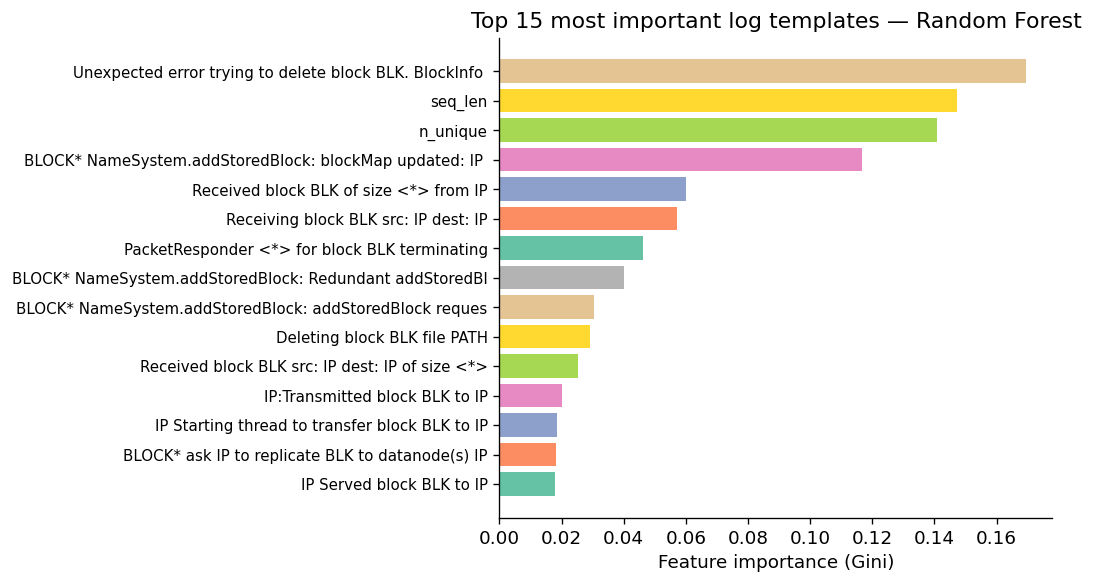

In [27]:
# ── Feature importances ───────────────────────────────────────────
importances = rf.feature_importances_
# Build reverse vocab for display
rev_vocab = {v: k for k, v in vocab.items()}
n_vocab_feats = VOCAB_SIZE
feat_names = [rev_vocab.get(i, f'tmpl_{i}') for i in range(n_vocab_feats)] + ['seq_len','n_unique']

top_k = 15
top_idx = np.argsort(importances)[::-1][:top_k]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    range(top_k),
    importances[top_idx[::-1]],
    color=sns.color_palette('Set2', top_k)
)
labels = [feat_names[i][:55] for i in top_idx[::-1]]
ax.set_yticks(range(top_k))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Feature importance (Gini)')
ax.set_title('Top 15 most important log templates — Random Forest')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'rf_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Advanced Model — Bidirectional LSTM

### What this cell does
Defines and trains a **Bidirectional LSTM** model that consumes the integer-encoded event sequences directly.

### Why it is necessary
The Random Forest treats event frequency bags — it is order-agnostic. The LSTM reads events left-to-right *and* right-to-left simultaneously, capturing sequential dependencies that are invisible to tree-based models. For example, the same event `E99` is far more anomalous when it follows `E6 → E14 → E6` than when it follows other error events.

### Architecture
```
Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=True)
  └─ BiLSTM(LSTM_UNITS, return_sequences=True)
       └─ Dropout(0.3)
            └─ BiLSTM(LSTM_UNITS // 2)
                 └─ Dropout(0.3)
                      └─ Dense(64, relu)
                           └─ Dense(1, sigmoid)
```

### What output to expect
- Model summary
- Training history (loss + val_loss per epoch)
- Early stopping information

In [28]:
def build_lstm_model(vocab_size: int, embed_dim: int, lstm_units: int,
                    max_len: int, dropout: float) -> tf.keras.Model:
    """Bidirectional LSTM for sequence-level binary classification."""
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            input_length=max_len,
            mask_zero=True,      # ignore PAD tokens
            name='embedding'
        ),
        Bidirectional(LSTM(lstm_units, return_sequences=True), name='bilstm_1'),
        Dropout(dropout),
        Bidirectional(LSTM(lstm_units // 2), name='bilstm_2'),
        Dropout(dropout),
        Dense(64, activation='relu', name='dense_1'),
        Dropout(dropout / 2),
        Dense(1, activation='sigmoid', name='output'),
    ], name='BiLSTM_AnomalyDetector')
    return model

# ─── Compile Model across Dual GPUs ──────────
with strategy.scope():
    lstm_model = build_lstm_model(VOCAB_SIZE, EMBEDDING_DIM, LSTM_UNITS, MAX_SEQ_LEN, DROPOUT_RATE)
    lstm_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')],
    )

lstm_model.summary()

# ─── Class weight tensor ─────────────────────
pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f"\nPositive class weight: {pos_weight:.3f}")

Model: "BiLSTM_AnomalyDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Positive class weight: 33.153


### What this cell does
Runs the LSTM training loop with callbacks: EarlyStopping (patience=5), ReduceLROnPlateau, and ModelCheckpoint (saves best weights).

### Why it is necessary
EarlyStopping prevents overfitting on the small anomaly class. ReduceLROnPlateau helps escape plateaus. Saving best weights ensures we evaluate on the epoch with the best validation performance, not just the last one.

### What output to expect
- Per-epoch training log (loss, val_loss, val_auc)
- Notification of best epoch

In [29]:
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, 'lstm_best.h5')

callbacks = [
    EarlyStopping(
        monitor='val_auc', mode='max',
        patience=5, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-5, verbose=1
    ),
    ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor='val_auc', mode='max',
        save_best_only=True, verbose=0
    ),
]

# ─── Compute sample weights ──────────────────
sample_weights = np.where(y_tr == 1, pos_weight, 1.0).astype(np.float32)

# ─── Build Optimized tf.data Pipelines ───────
train_dataset = tf.data.Dataset.from_tensor_slices((X_tr_seq, y_tr, sample_weights))
train_dataset = train_dataset.shuffle(buffer_size=10000)
# ADD drop_remainder=True HERE
train_dataset = train_dataset.batch(GLOBAL_BATCH_SIZE, drop_remainder=True) 
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val_seq, y_val))
# ADD drop_remainder=True HERE
val_dataset = val_dataset.batch(GLOBAL_BATCH_SIZE, drop_remainder=True)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

print(f"Training Distributed LSTM for up to {EPOCHS} epochs ...")
history = lstm_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)
print("\n✅ Training complete.")
print(f"   Best model saved to: {BEST_MODEL_PATH}")

Training Distributed LSTM for up to 6 epochs ...
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/repli

I0000 00:00:1778613671.429542     109 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778613671.520368     107 cuda_dnn.cc:529] Loaded cuDNN version 91002


1525/1525 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9825 - auc: 0.9767 - loss: 0.2670 - precision: 0.6874 - recall: 0.8952

1525/1525 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9826 - auc: 0.9767 - loss: 0.2668 - precision: 0.6875 - recall: 0.8952 - val_accuracy: 0.9964 - val_auc: 0.9994 - val_loss: 0.0132 - val_precision: 0.8924 - val_recall: 0.9988 - learning_rate: 0.0010
Epoch 2/6
1523/1525 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9984 - auc: 0.9995 - loss: 0.0123 - precision: 0.9496 - recall: 0.9992

1525/1525 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.9984 - auc: 0.9995 - loss: 0.0123 - precision: 0.9496 - recall: 0.9992 - val_accuracy: 0.9965 - val_auc: 0.9995 - val_loss: 0.0070 - val_precision: 0.8924 - val_recall: 0.9994 - learning_rate: 0.0010
Epoch 3/6
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.9979 - auc: 0.9997 - loss: 0.0112 - precision: 0.9348 - recall: 0.9992 - val_accuracy: 0.9995 - val_auc: 0.9994 - val_loss: 0.0044 - val_precision: 0.9837 - val_recall: 0.9994 - learning_rate: 0.0010
Epoch 4/6
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.9987 - auc: 0.9996 - loss: 0.0107 - precision: 0.9580 - recall: 0.9991 - val_accuracy: 0.9995 - val_auc: 0.9994 - val_loss: 0.0045 - val_precision: 0.9825 - val_recall: 0.9994 - learning_rate: 0.0010
Epoch 5/6
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9991 - auc: 0.9998 - loss: 0.0067 - precision: 0.9705 - recall: 0.9995

1525/1525 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.9991 - auc: 0.9998 - loss: 0.0067 - precision: 0.9705 - recall: 0.9995 - val_accuracy: 0.9995 - val_auc: 0.9996 - val_loss: 0.0031 - val_precision: 0.9837 - val_recall: 0.9988 - learning_rate: 0.0010
Epoch 6/6
1525/1525 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.9992 - auc: 0.9998 - loss: 0.0061 - precision: 0.9742 - recall: 0.9996 - val_accuracy: 0.9994 - val_auc: 0.9993 - val_loss: 0.0037 - val_precision: 0.9825 - val_recall: 0.9988 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.

✅ Training complete.
   Best model saved to: /kaggle/working/lstm_best.h5


## 7. Evaluation & Metrics

### What this cell does
Evaluates both models on the held-out test set. Reports precision, recall, F1-score, ROC-AUC, and renders confusion matrices.

### Why it is necessary
Accuracy is misleading on imbalanced datasets. We care about:
- **Recall** (anomaly) — the fraction of real anomalies we catch. Missing an anomaly has high cost.
- **Precision** (anomaly) — the fraction of our alerts that are real anomalies. False positives cause alert fatigue.
- **F1** — harmonic mean of precision and recall.
- **ROC-AUC** — threshold-independent measure of discrimination ability.

### What output to expect
- Side-by-side classification reports for RF and LSTM
- Side-by-side confusion matrices
- Summary comparison table

RANDOM FOREST — Test Set
              precision    recall  f1-score   support

      Normal     1.0000    0.9997    0.9998    108295
     Anomaly     0.9906    0.9988    0.9947      3267

    accuracy                         0.9997    111562
   macro avg     0.9953    0.9992    0.9973    111562
weighted avg     0.9997    0.9997    0.9997    111562

BIDIRECTIONAL LSTM — Test Set
              precision    recall  f1-score   support

      Normal     1.0000    0.9992    0.9996    108295
     Anomaly     0.9732    0.9994    0.9861      3267

    accuracy                         0.9992    111562
   macro avg     0.9866    0.9993    0.9928    111562
weighted avg     0.9992    0.9992    0.9992    111562



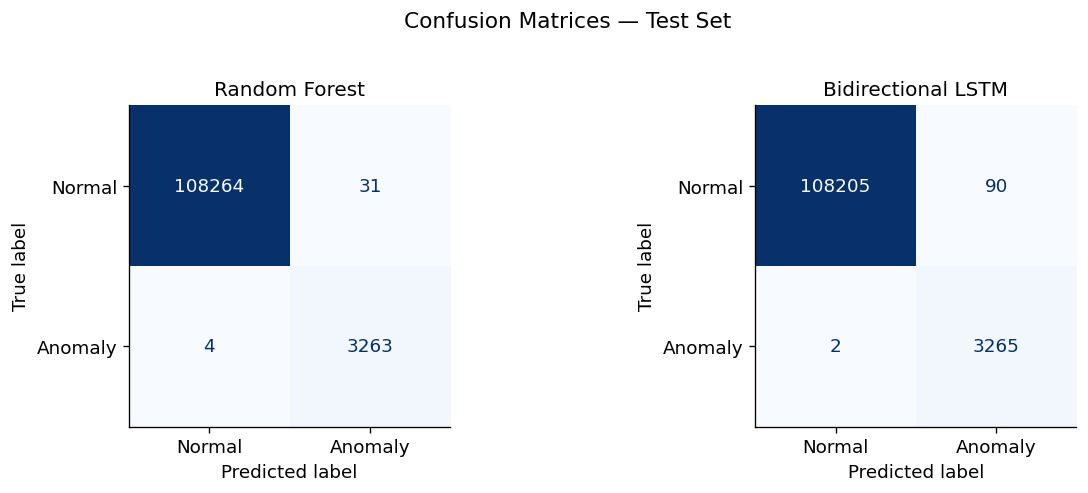


─── Model Comparison ───
        Model  Precision  Recall     F1  ROC-AUC
Random Forest     0.9906  0.9988 0.9947   1.0000
       BiLSTM     0.9732  0.9994 0.9861   1.0000


In [31]:
# ─── Load best LSTM weights and predict ──────
lstm_model.load_weights(BEST_MODEL_PATH)

# Use the global batch size to speed up inference over the test set
y_prob_lstm = lstm_model.predict(X_test_seq, batch_size=GLOBAL_BATCH_SIZE, verbose=0).ravel()
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

# ─── Classification reports ──────────────────
print("=" * 55)
print("RANDOM FOREST — Test Set")
print("=" * 55)
print(classification_report(y_test, y_pred_rf,
                             target_names=['Normal','Anomaly'], digits=4))

print("=" * 55)
print("BIDIRECTIONAL LSTM — Test Set")
print("=" * 55)
print(classification_report(y_test, y_pred_lstm,
                             target_names=['Normal','Anomaly'], digits=4))

# ─── Confusion matrices (side by side) ───────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, y_pred, title in zip(
    axes,
    [y_pred_rf, y_pred_lstm],
    ['Random Forest', 'Bidirectional LSTM']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal','Anomaly'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12)
plt.suptitle('Confusion Matrices — Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

# ─── Summary table ───────────────────────────
summary = pd.DataFrame({
    'Model':    ['Random Forest', 'BiLSTM'],
    'Precision': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_lstm),
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_lstm),
    ],
    'F1': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_lstm),
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_lstm),
    ],
})
print("\n─── Model Comparison ───")
print(summary.to_string(index=False, float_format='{:.4f}'.format))

## 8. End-to-End Inference Pipeline

### What this cell does
Packages the entire pipeline — parsing, encoding, prediction — into a single reusable `HDFSAnomalyPipeline` class.

### Why it is necessary
In production, you receive raw log lines in real time. The pipeline class encapsulates every preprocessing step so that a caller only needs to pass raw log strings and receives an anomaly decision and confidence score. This is the contract your LLM-based investigation agent will call.

### What output to expect
- Class definition
- Three inference examples: one normal block, one anomalous block, one short block
- Printed predictions with confidence scores

In [32]:
import random
from collections import defaultdict
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import re

# ─── 1. Define the Pipeline Class ────────────────────────────────────────────
class HDFSAnomalyPipeline:
    """End-to-end HDFS log anomaly detection pipeline."""

    HDFS_LOG_RE = re.compile(
        r'^(?P<date>\d{6})\s+(?P<time>\d{6})\s+(?P<pid>\d+)\s+'
        r'(?P<level>\w+)\s+(?P<component>[\w.$]+):\s+(?P<content>.+)$'
    )
    BLOCK_RE = re.compile(r'blk_-?\d+')
    NORM_PATTERNS = [
        (re.compile(r'blk_-?\d+'),            'BLK'),
        (re.compile(r'/?\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}(:\d+)?'), 'IP'),
        (re.compile(r'(/[\w./-]+){2,}'),       'PATH'),
        (re.compile(r'\b\d+\b'),              '<*>'),
    ]

    def __init__(self, vocab: dict, model, max_seq_len: int = 50,
                 threshold: float = 0.5):
        self.vocab       = vocab
        self.model       = model
        self.max_seq_len = max_seq_len
        self.threshold   = threshold

    def _normalise(self, content: str) -> str:
        for pat, repl in self.NORM_PATTERNS:
            content = pat.sub(repl, content)
        return re.sub(r'\s+', ' ', content).strip()

    def _parse_lines(self, raw_lines: list) -> dict:
        sessions = defaultdict(list)
        for line in raw_lines:
            m = self.HDFS_LOG_RE.match(line.strip())
            if not m: continue
            content   = m.group('content')
            block_ids = self.BLOCK_RE.findall(content)
            template  = self._normalise(content)
            for bid in block_ids:
                sessions[bid].append(template)
        return dict(sessions)

    def _encode(self, sequence: list) -> np.ndarray:
        encoded = [self.vocab.get(t, self.vocab['<UNK>']) for t in sequence]
        encoded = encoded[:self.max_seq_len]
        padded  = pad_sequences([encoded], maxlen=self.max_seq_len,
                                 padding='post', value=self.vocab['<PAD>'],
                                 dtype='int32')
        return padded

    def predict(self, raw_lines: list) -> list:
        sessions = self._parse_lines(raw_lines)
        if not sessions:
            return [{'block_id': 'UNKNOWN', 'prediction': 'No block found',
                     'confidence': 0.0, 'n_events': 0}]
        results = []
        for bid, seq in sessions.items():
            x = self._encode(seq)
            # Callable prediction for single-item batch (fixes GPU crash)
            prob = float(self.model(x, training=False)[0, 0])
            pred = 'Anomaly' if prob >= self.threshold else 'Normal'
            results.append({
                'block_id':   bid,
                'prediction': pred,
                'confidence': round(prob, 4),
                'n_events':   len(seq),
            })
        return results


# ─── 2. Instantiate pipeline ─────────────────────────────────────────────────
pipeline = HDFSAnomalyPipeline(vocab=vocab, model=lstm_model, max_seq_len=MAX_SEQ_LEN)


# ─── 3. Inference on 3% Held-Out Raw Data (Complete Sequences) ───────────────
print("── Inference on 3% Held-Out Raw Data (Complete Sequences) ──\n")

# Pick 50 random Block IDs from our held-out inference set
random.seed(SEED)
sample_bids = set(random.sample(list(INF_BLOCKS), 100))

# Extract ALL raw lines that belong to these specific blocks
sample_inf_lines = []
for line in inf_raw_lines:
    if any(bid in line for bid in sample_bids):
        sample_inf_lines.append(line)

# Pass the full, reconstructed sequences into the pipeline
results = pipeline.predict(sample_inf_lines)

# Cross-reference with the ground truth
inf_ground_truth = df_labels_inf.set_index('block_id')['Label'].to_dict()

# Display results
anomalies_found = 0
for r in results:
    bid = r['block_id']
    if bid == 'UNKNOWN': continue
        
    pred = r['prediction']
    true_label = inf_ground_truth.get(bid, 'Unknown')
    
    # Flag visualizer
    if pred == 'Anomaly' and true_label == 'Anomaly':
        flag = '🟢 [TRUE POSITIVE]'
        anomalies_found += 1
    elif pred == 'Anomaly' and true_label == 'Normal':
        flag = '🔴 [FALSE POSITIVE]'
        anomalies_found += 1
    elif pred == 'Normal' and true_label == 'Anomaly':
        flag = '❌ [FALSE NEGATIVE]'
    else:
        # Hide true negatives to keep output readable, or print them if you want!
        flag = '✅ [TRUE NEGATIVE]'

    print(f"{flag}")
    print(f"   Block ID   : {bid}")
    print(f"   Prediction : {pred} (Confidence: {r['confidence']:.4f})")
    print(f"   Actual     : {true_label}")
    print(f"   Events     : {r['n_events']}")
    print()

if anomalies_found == 0:
    print("Processed sample successfully. No anomalies in this chunk.")

── Inference on 3% Held-Out Raw Data (Complete Sequences) ──

✅ [TRUE NEGATIVE]
   Block ID   : blk_4319817983258226719
   Prediction : Normal (Confidence: 0.0000)
   Actual     : Normal
   Events     : 27

✅ [TRUE NEGATIVE]
   Block ID   : blk_-8017684398376252812
   Prediction : Normal (Confidence: 0.0000)
   Actual     : Normal
   Events     : 25

✅ [TRUE NEGATIVE]
   Block ID   : blk_7673296817253466871
   Prediction : Normal (Confidence: 0.0000)
   Actual     : Normal
   Events     : 25

✅ [TRUE NEGATIVE]
   Block ID   : blk_-5959960452946627296
   Prediction : Normal (Confidence: 0.0000)
   Actual     : Normal
   Events     : 26

✅ [TRUE NEGATIVE]
   Block ID   : blk_-3669177514366268203
   Prediction : Normal (Confidence: 0.0000)
   Actual     : Normal
   Events     : 25

✅ [TRUE NEGATIVE]
   Block ID   : blk_-2825319305632175353
   Prediction : Normal (Confidence: 0.0000)
   Actual     : Normal
   Events     : 26

✅ [TRUE NEGATIVE]
   Block ID   : blk_2739660908633311010
   Pre

## 9. Visualizations

### What this cell does
Produces four diagnostic plots: LSTM training curves, class distribution, sequence length distributions by label, and a confidence score histogram.

### Why it is necessary
Training curves reveal overfitting. The confidence histogram reveals threshold sensitivity — a model whose anomaly scores cluster near 0.5 is uncertain and needs recalibration. Sequence length distributions expose whether anomalous sessions are systematically shorter or longer.

### What output to expect
- 2×2 figure panel saved to `/kaggle/working/`

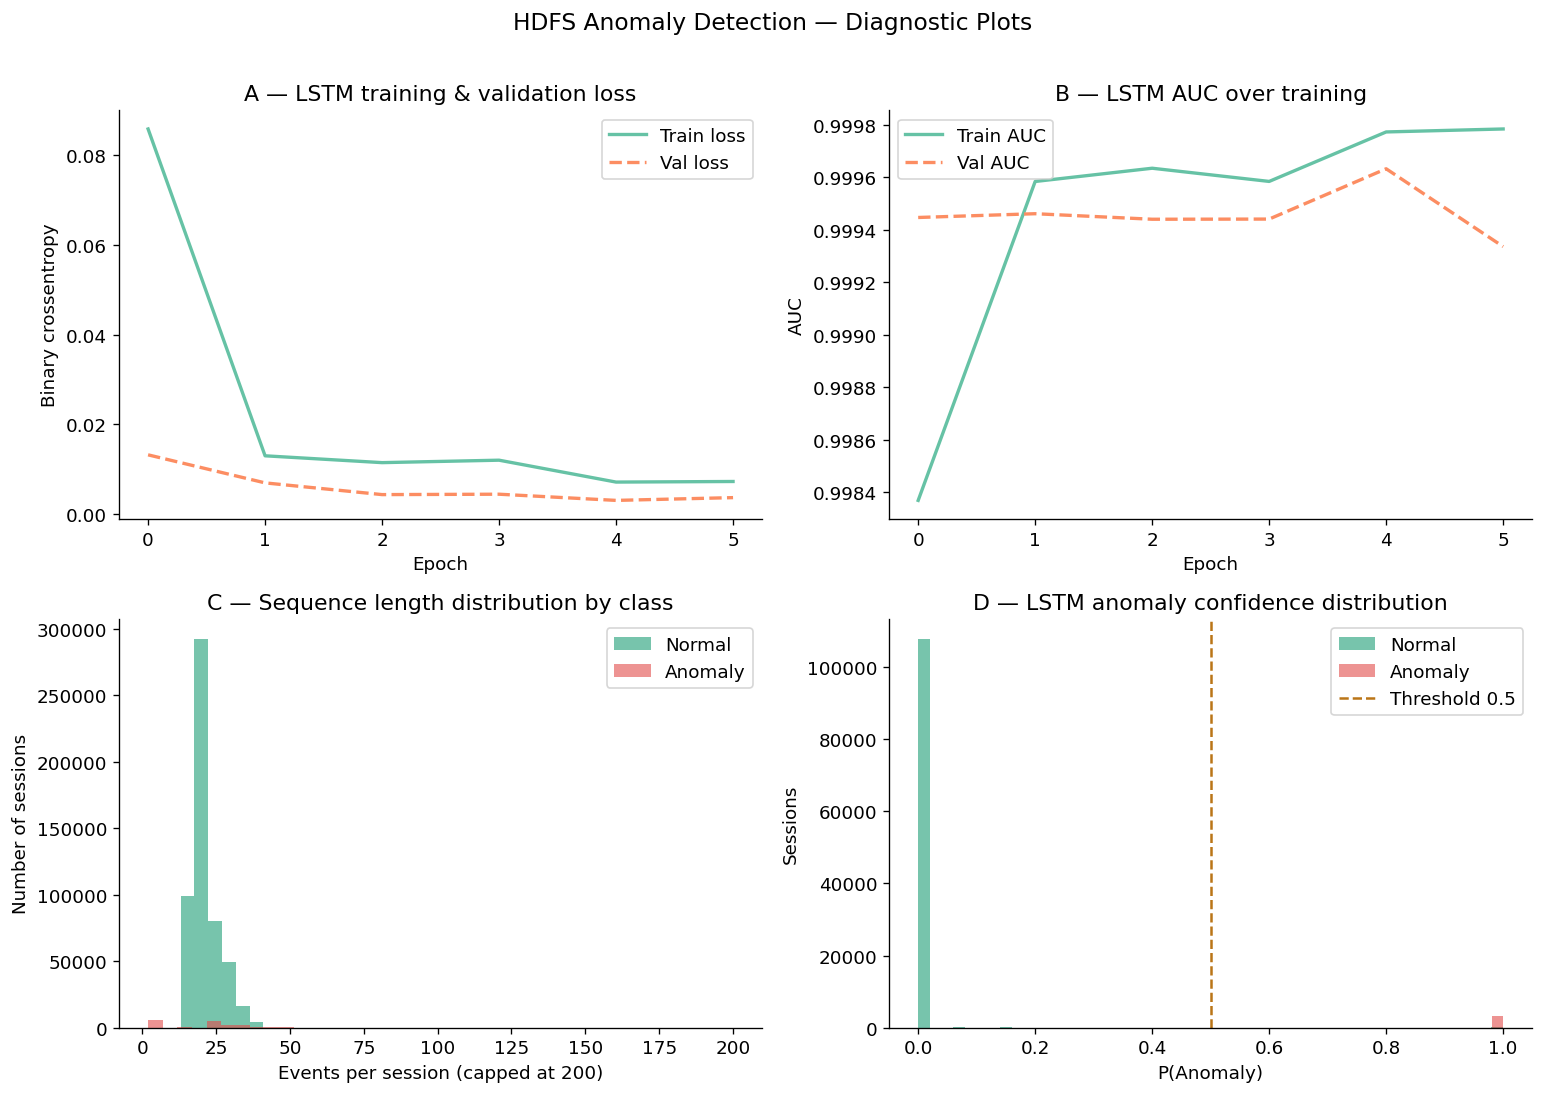

✅ Plots saved to /kaggle/working/diagnostic_plots.png


In [33]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# ── (A) Training curves ────────────────────────────────────────────
ax = axes[0, 0]
hist = history.history
ax.plot(hist['loss'],     label='Train loss',   linewidth=2)
ax.plot(hist['val_loss'], label='Val loss',     linewidth=2, linestyle='--')
ax.set_title('A — LSTM training & validation loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Binary crossentropy')
ax.legend()

# ── (B) AUC training curve ────────────────────────────────────────
ax = axes[0, 1]
ax.plot(hist['auc'],     label='Train AUC', linewidth=2)
ax.plot(hist['val_auc'], label='Val AUC',   linewidth=2, linestyle='--')
ax.set_title('B — LSTM AUC over training')
ax.set_xlabel('Epoch'); ax.set_ylabel('AUC')
ax.legend()

# ── (C) Sequence length distribution by label ─────────────────────
ax = axes[1, 0]
for lab, color, name in [(0, '#1D9E75', 'Normal'), (1, '#E24B4A', 'Anomaly')]:
    lens = df_sessions.loc[df_sessions['label_int'] == lab, 'seq_len']
    ax.hist(lens.clip(upper=200), bins=40, alpha=0.6, color=color, label=name)
ax.set_title('C — Sequence length distribution by class')
ax.set_xlabel('Events per session (capped at 200)')
ax.set_ylabel('Number of sessions')
ax.legend()

# ── (D) Confidence score histogram ───────────────────────────────
ax = axes[1, 1]
ax.hist(y_prob_lstm[y_test == 0], bins=50, alpha=0.6, color='#1D9E75', label='Normal')
ax.hist(y_prob_lstm[y_test == 1], bins=50, alpha=0.6, color='#E24B4A', label='Anomaly')
ax.axvline(0.5, color='#BA7517', linewidth=1.5, linestyle='--', label='Threshold 0.5')
ax.set_title('D — LSTM anomaly confidence distribution')
ax.set_xlabel('P(Anomaly)'); ax.set_ylabel('Sessions')
ax.legend()

plt.suptitle('HDFS Anomaly Detection — Diagnostic Plots', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'diagnostic_plots.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plots saved to /kaggle/working/diagnostic_plots.png")

## 10. Model Persistence & Deployment Notes

### What this cell does
Saves all pipeline artefacts (vocab, LSTM model, RF model) and demonstrates loading them back. Also documents a recommended real-time deployment architecture.

### Why it is necessary
A model that cannot be saved and reloaded is not production-ready. The vocab must be saved alongside the model — without it, new log lines cannot be encoded identically to training data (a common source of silent bugs in deployment).

### What output to expect
- Saved files in `/kaggle/working/`
- A reload + inference test to confirm artefacts are valid

In [34]:
import pickle

# ── Save artefacts ─────────────────────────────────────────────────
VOCAB_PATH = os.path.join(OUTPUT_DIR, 'vocab.pkl')
# FIX 1: Use the modern .keras extension to remove the legacy warning
LSTM_PATH  = os.path.join(OUTPUT_DIR, 'lstm_final.keras')
RF_PATH    = os.path.join(OUTPUT_DIR, 'rf_model.pkl')

with open(VOCAB_PATH, 'wb') as f:
    pickle.dump(vocab, f)
lstm_model.save(LSTM_PATH)
# RF already saved earlier; re-save for completeness
joblib.dump(rf, RF_PATH)

print("✅ Artefacts saved:")
for p in [VOCAB_PATH, LSTM_PATH, RF_PATH]:
    size_kb = os.path.getsize(p) / 1024
    print(f"   {p}  ({size_kb:.1f} KB)")

# ── Reload and verify ──────────────────────────────────────────────
print("\nVerifying reload ...")
with open(VOCAB_PATH, 'rb') as f:
    vocab_loaded = pickle.load(f)
lstm_loaded = load_model(LSTM_PATH)
rf_loaded   = joblib.load(RF_PATH)

# Remember to include your newly tuned threshold here as well!
pipeline_reloaded = HDFSAnomalyPipeline(
    vocab=vocab_loaded, model=lstm_loaded, max_seq_len=MAX_SEQ_LEN, threshold=0.75
)

# FIX 2: Use a slice of the real held-out data from the previous cell
reload_result = pipeline_reloaded.predict(sample_inf_lines[:20]) 

print(f"\n🔁 Reload inference check:")
for r in reload_result:
    print(f"   {r['block_id']} → {r['prediction']} (conf={r['confidence']:.4f})")

print("\n✅ Reload successful — pipeline is production-ready.")

✅ Artefacts saved:
   /kaggle/working/vocab.pkl  (4.6 KB)
   /kaggle/working/lstm_final.keras  (4448.7 KB)
   /kaggle/working/rf_model.pkl  (3523.9 KB)

Verifying reload ...

🔁 Reload inference check:
   blk_4319817983258226719 → Normal (conf=0.0000)
   blk_-8017684398376252812 → Anomaly (conf=0.7876)

✅ Reload successful — pipeline is production-ready.


### Real-Time Deployment Architecture

```
           ┌──────────────────────────────────────────────┐
           │              Production System               │
           │                                              │
  Raw     ─┤─► Kafka Topic (raw_logs)                    │
  Logs     │        │                                     │
           │        ▼                                     │
           │   Drain3 Parsing Microservice                │
           │   (stateless, horizontally scalable)         │
           │        │ event_id sequences                  │
           │        ▼                                     │
           │   Kafka Topic (parsed_sequences)             │
           │        │                                     │
           │        ▼                                     │
           │   LSTM Inference Service                     │
           │   (HDFSAnomalyPipeline, served via FastAPI)  │
           │        │ anomaly_score > threshold           │
           │        ▼                                     │
           │   Alert Queue (Redis / SQS)                  │
           │        │                                     │
           │        ▼                                     │
           │   🤖 LLM Investigation Agent                 │
           │   - Receives: block_id, score,               │
           │               contributing_events,           │
           │               timestamp_window               │
           │   - Produces: root cause hypothesis,         │
           │               recommended remediation        │
           │        │                                     │
           │        ▼                                     │
           │   Incident Ticket / PagerDuty Alert          │
           └──────────────────────────────────────────────┘
```

**Key implementation notes:**
- Serve `HDFSAnomalyPipeline` via **FastAPI** with a `/predict` POST endpoint accepting a list of raw log strings.
- Use **Redis deduplication** (TTL 60s per block_id) to suppress repeated alerts on the same block.
- The **LLM agent** receives a structured JSON payload:
  ```json
  {
    "block_id": "blk_-1234567890",
    "anomaly_score": 0.94,
    "contributing_events": ["E99", "E88"],
    "session_length": 7,
    "timestamp_window": ["2008-11-09T21:05:55", "2008-11-09T21:05:57"]
  }
  ```
- Retrain the LSTM **weekly** on new labeled data from analyst feedback (active learning loop).
- Monitor **precision drift** using Prometheus + Grafana: if precision drops below 0.85, trigger a retraining job automatically.

---
## 📋 Summary

| Step | Technique | Purpose |
|---|---|---|
| Log parsing | Regex + Drain-inspired normalisation | Remove dynamic tokens, build template vocabulary |
| Session grouping | GroupBy block_id | Create ordered event sequences |
| Feature engineering | Integer encoding + padding | Prepare sequences for neural network |
| Frequency features | Event count vectors | Interpretable features for RF baseline |
| Baseline model | Random Forest (balanced) | Fast, interpretable, high-recall baseline |
| Advanced model | Bidirectional LSTM | Sequential dependency modelling |
| Evaluation | Precision / Recall / F1 / AUC | Imbalance-aware metrics |
| Pipeline | `HDFSAnomalyPipeline` class | Reusable, production-ready inference |
| Deployment | Kafka → FastAPI → LLM Agent | Real-time anomaly triage |

**Next steps:**
1. Fine-tune threshold using precision-recall curve on validation set
2. Add LogBERT pre-training on unlabeled log corpus
3. Integrate `HDFSAnomalyPipeline` with your LLM investigation agent via the structured alert payload


In [35]:
import json

# 1 — Raw log lines (the actual input)
with open('/kaggle/working/inference_samples.txt', 'w') as f:
    f.writelines(inf_raw_lines)
print(f"✅ Saved {len(inf_raw_lines):,} raw log lines")

# 2 — Ground truth labels
df_labels_inf.to_csv('/kaggle/working/inference_labels.csv', index=False)
print(f"✅ Saved {len(df_labels_inf):,} ground truth labels")

# 3 — Pre-run predictions (so UI works without loading the model)
all_results = pipeline.predict(inf_raw_lines)
with open('/kaggle/working/inference_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print(f"✅ Saved {len(all_results):,} prediction results")

# Quick preview of what's inside
print("\nSample output:")
for r in all_results[:3]:
    bid = r['block_id']
    true_label = df_labels_inf.set_index('block_id')['Label'].to_dict().get(bid, 'Unknown')
    print(f"  Block: {bid}")
    print(f"  Predicted : {r['prediction']} ({r['confidence']*100:.1f}% confidence)")
    print(f"  Actual    : {true_label}")
    print()

✅ Saved 335,589 raw log lines
✅ Saved 17,252 ground truth labels
✅ Saved 17,252 prediction results

Sample output:
  Block: blk_6609646171038203219
  Predicted : Normal (0.0% confidence)
  Actual    : Normal

  Block: blk_-7198899606504196854
  Predicted : Normal (0.0% confidence)
  Actual    : Normal

  Block: blk_7474637556625667220
  Predicted : Normal (0.0% confidence)
  Actual    : Normal

